# Actividad 14 – Limpieza de ruido

**Objetivo**: usar morfología para limpiar ruido en imágenes binarias.

En esta actividad vamos a:
1. Cargar una imagen
2. Aplicar umbralización de Otsu
3. Aplicar operación de apertura (eliminar ruido pequeño)
4. Aplicar operación de cierre (rellenar huecos)
5. Comparar resultados

## 1. Importar librerías necesarias

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Configurar matplotlib para mostrar imágenes en el notebook
%matplotlib inline

## 2. Cargar imagen y convertir a escala de grises

✓ Imagen cargada correctamente
✓ Imagen convertida a escala de grises


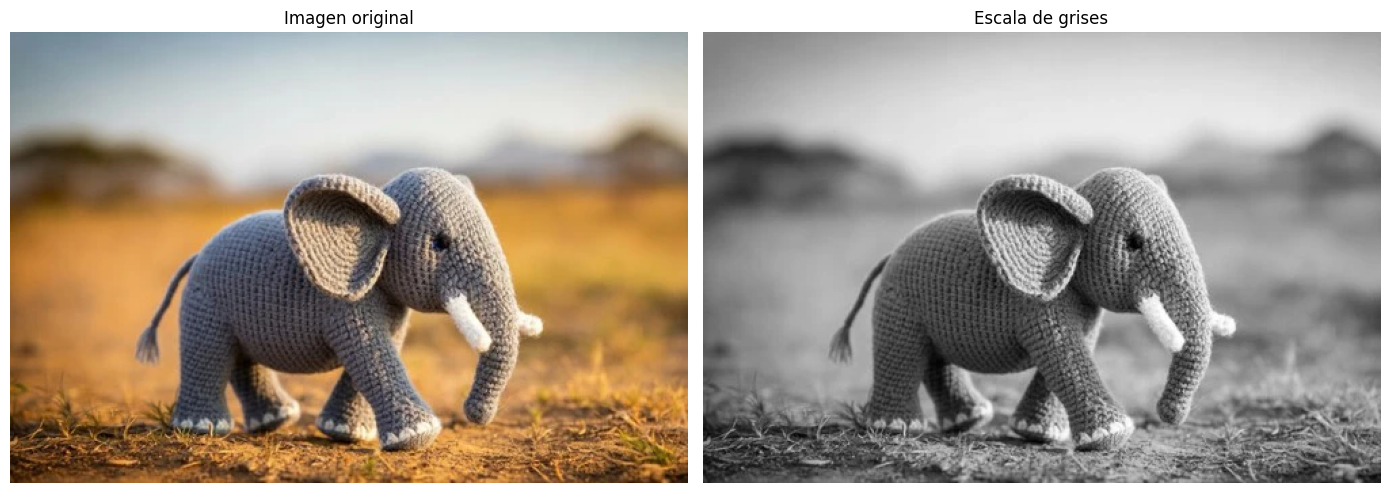

In [2]:
# Cargar la imagen
imagen = cv2.imread('imagen.webp')

# Verificar que la imagen se cargó correctamente
if imagen is None:
    print("Error: No se pudo cargar la imagen. Verifica la ruta del archivo.")
else:
    print("✓ Imagen cargada correctamente")
    
    # Convertir a escala de grises
    imagen_gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    print("✓ Imagen convertida a escala de grises")
    
    # Mostrar imagen original
    imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(imagen_rgb)
    axes[0].set_title('Imagen original')
    axes[0].axis('off')
    
    axes[1].imshow(imagen_gris, cmap='gray')
    axes[1].set_title('Escala de grises')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

## 3. Aplicar umbralización de Otsu

Otsu calcula automáticamente el umbral óptimo y genera una imagen binaria.

✓ Umbralización de Otsu aplicada
  Umbral calculado: 134.00
  Píxeles blancos: 101443
  Píxeles negros: 65057


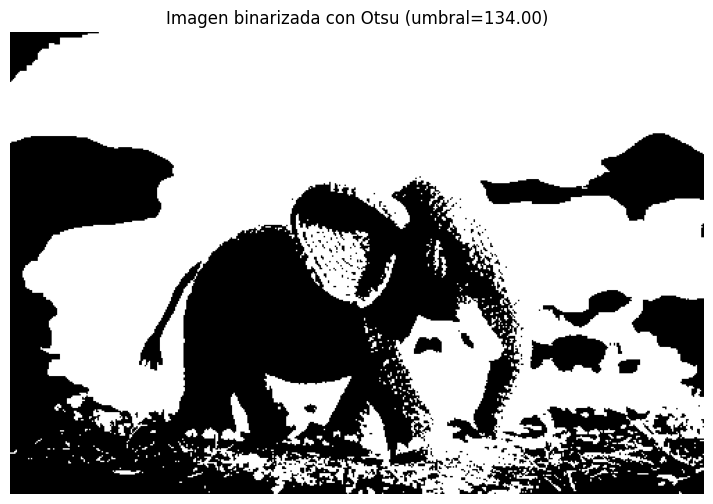

In [3]:
# Aplicar método de Otsu
retval_otsu, imagen_otsu = cv2.threshold(imagen_gris, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print(f"✓ Umbralización de Otsu aplicada")
print(f"  Umbral calculado: {retval_otsu:.2f}")
print(f"  Píxeles blancos: {np.sum(imagen_otsu == 255)}")
print(f"  Píxeles negros: {np.sum(imagen_otsu == 0)}")

plt.figure(figsize=(10, 6))
plt.imshow(imagen_otsu, cmap='gray')
plt.title(f'Imagen binarizada con Otsu (umbral={retval_otsu:.2f})')
plt.axis('off')
plt.show()

## 4. Aplicar apertura (opening)

La apertura elimina ruido pequeño: primero erosiona (elimina píxeles blancos en bordes) y luego dilata (recupera el tamaño original).

✓ Apertura aplicada
  Kernel: 5x5
  Efecto: elimina ruido pequeño (píxeles blancos aislados)
  Píxeles eliminados: 8067


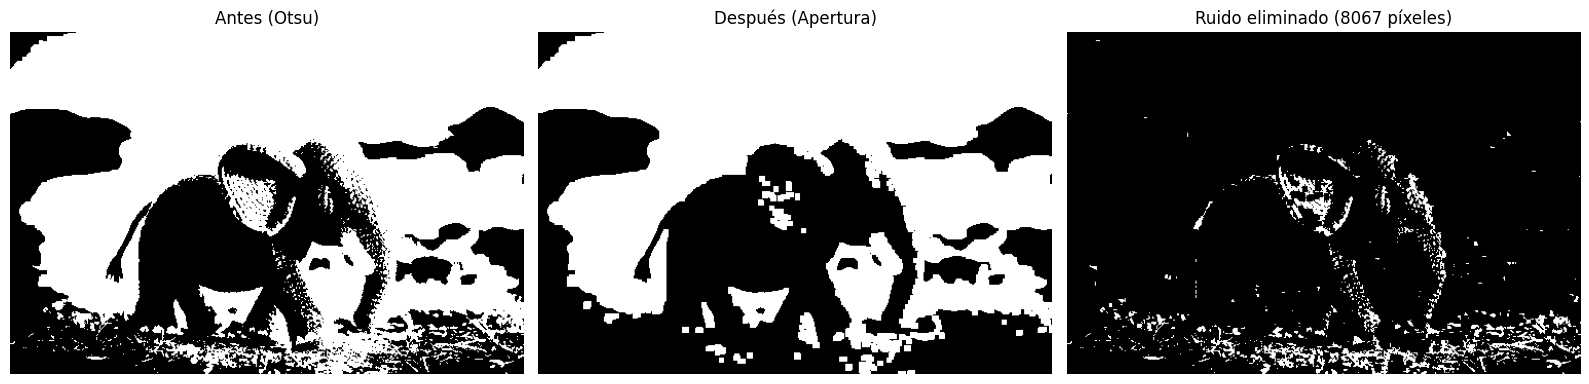

In [4]:
# Definir kernel (elemento estructurante)
kernel_size = 5
kernel = np.ones((kernel_size, kernel_size), np.uint8)

# Aplicar apertura (erosión seguida de dilatación)
imagen_opening = cv2.morphologyEx(imagen_otsu, cv2.MORPH_OPEN, kernel)

print(f"✓ Apertura aplicada")
print(f"  Kernel: {kernel_size}x{kernel_size}")
print(f"  Efecto: elimina ruido pequeño (píxeles blancos aislados)")

# Calcular diferencia
diferencia_opening = cv2.absdiff(imagen_otsu, imagen_opening)
pixeles_eliminados = np.sum(diferencia_opening == 255)

print(f"  Píxeles eliminados: {pixeles_eliminados}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(imagen_otsu, cmap='gray')
axes[0].set_title('Antes (Otsu)')
axes[0].axis('off')

axes[1].imshow(imagen_opening, cmap='gray')
axes[1].set_title(f'Después (Apertura)')
axes[1].axis('off')

axes[2].imshow(diferencia_opening, cmap='gray')
axes[2].set_title(f'Ruido eliminado ({pixeles_eliminados} píxeles)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 5. Aplicar cierre (closing)

El cierre rellena pequeños huecos: primero dilata (añade píxeles blancos) y luego erosiona (reduce exceso).

✓ Cierre aplicado
  Kernel: 5x5
  Efecto: rellena huecos pequeños (píxeles negros dentro de objetos)
  Píxeles rellenados: 7850


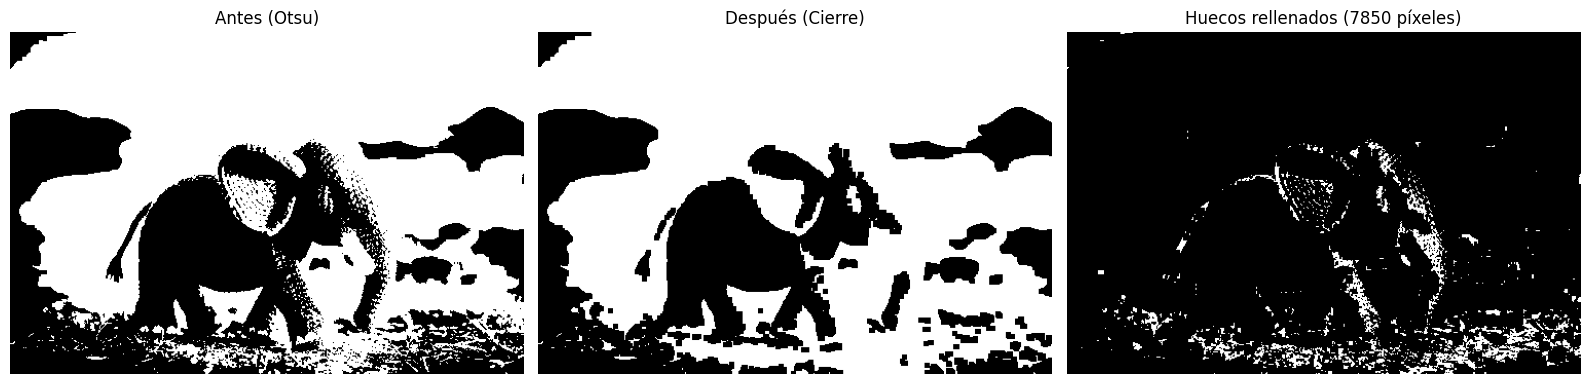

In [5]:
# Aplicar cierre (dilatación seguida de erosión)
imagen_closing = cv2.morphologyEx(imagen_otsu, cv2.MORPH_CLOSE, kernel)

print(f"✓ Cierre aplicado")
print(f"  Kernel: {kernel_size}x{kernel_size}")
print(f"  Efecto: rellena huecos pequeños (píxeles negros dentro de objetos)")

# Calcular diferencia
diferencia_closing = cv2.absdiff(imagen_otsu, imagen_closing)
pixeles_rellenados = np.sum(diferencia_closing == 255)

print(f"  Píxeles rellenados: {pixeles_rellenados}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(imagen_otsu, cmap='gray')
axes[0].set_title('Antes (Otsu)')
axes[0].axis('off')

axes[1].imshow(imagen_closing, cmap='gray')
axes[1].set_title(f'Después (Cierre)')
axes[1].axis('off')

axes[2].imshow(diferencia_closing, cmap='gray')
axes[2].set_title(f'Huecos rellenados ({pixeles_rellenados} píxeles)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 6. Comparar todos los resultados

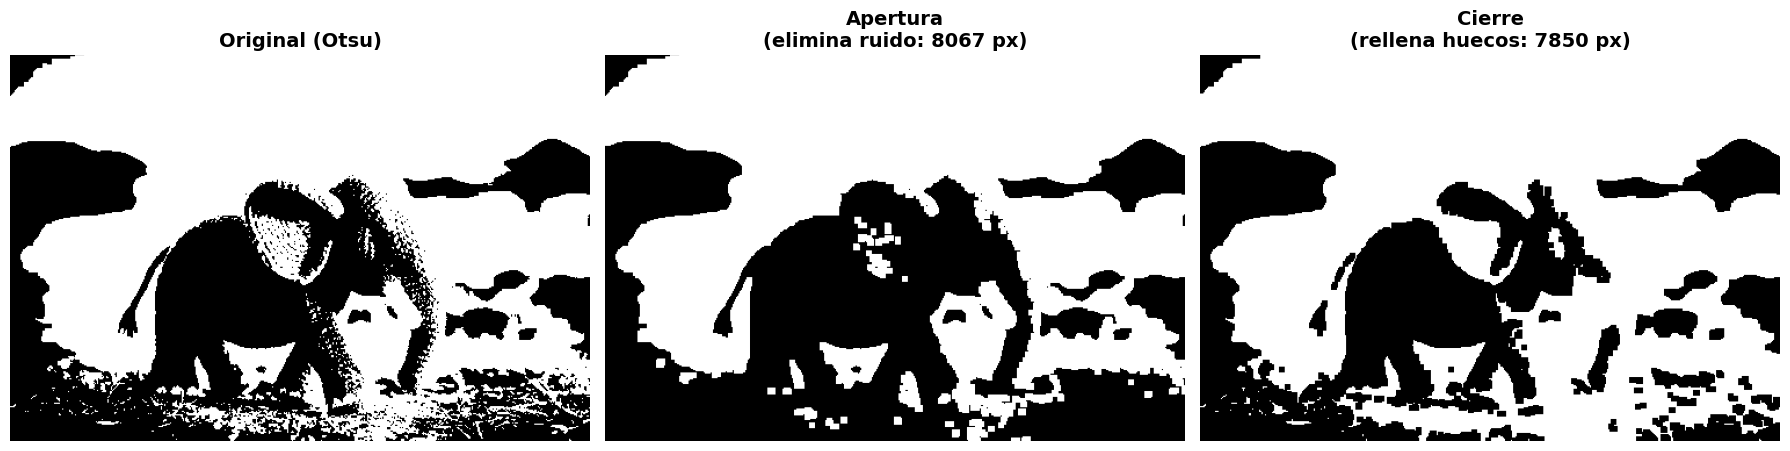


RESUMEN DE OPERACIONES MORFOLÓGICAS
Kernel usado: 5x5

APERTURA (erosión + dilatación):
  • Píxeles eliminados: 8067
  • Uso: eliminar ruido blanco pequeño

CIERRE (dilatación + erosión):
  • Píxeles rellenados: 7850
  • Uso: rellenar huecos negros pequeños


In [6]:
# Comparar las tres versiones
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(imagen_otsu, cmap='gray')
axes[0].set_title('Original (Otsu)', fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(imagen_opening, cmap='gray')
axes[1].set_title(f'Apertura\n(elimina ruido: {pixeles_eliminados} px)', fontsize=14, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(imagen_closing, cmap='gray')
axes[2].set_title(f'Cierre\n(rellena huecos: {pixeles_rellenados} px)', fontsize=14, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("RESUMEN DE OPERACIONES MORFOLÓGICAS")
print("="*60)
print(f"Kernel usado: {kernel_size}x{kernel_size}")
print(f"\nAPERTURA (erosión + dilatación):")
print(f"  • Píxeles eliminados: {pixeles_eliminados}")
print(f"  • Uso: eliminar ruido blanco pequeño")
print(f"\nCIERRE (dilatación + erosión):")
print(f"  • Píxeles rellenados: {pixeles_rellenados}")
print(f"  • Uso: rellenar huecos negros pequeños")
print("="*60)